# Terna mix elettrico 2015-2024 — analisi tecnica

**Dataset**: `terna_electricity_by_source` (clean parquet su GCS)

**Periodo**: 2015-2024 (escluso 2017 per anomalie metodologiche)

**Fonte**: Terna S.p.A.

Questo notebook valida e analizza la serie storica della produzione elettrica netta italiana.
Per la narrativa pubblica, vedi il [README](../README.md).

In [1]:
import duckdb
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 150})

FIGURES_DIR = Path('..') / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

con = duckdb.connect()
con.execute('INSTALL httpfs; LOAD httpfs;')
con.execute("SET s3_region='us-east-1';")

GCS_PATH = 'gs://dataciviclab-clean/terna_electricity_by_source/*/terna_electricity_by_source_*_clean.parquet'

In [2]:
# 1. Verifica copertura
cov = con.execute(f'''
SELECT anno, tipo_produzione,
       COUNT(*) AS righe,
       COUNT(DISTINCT regione) AS regioni,
       COUNT(DISTINCT provincia) AS province,
       ROUND(SUM(produzione_gwh)) AS totale_gwh
FROM read_parquet('{GCS_PATH}')
GROUP BY anno, tipo_produzione
ORDER BY anno, tipo_produzione
''').fetchdf()
cov

,anno,tipo_produzione,righe,regioni,province,totale_gwh
0,2015,Lorda,415,20,110,282994.0
1,2015,Netta,415,20,110,282994.0
2,2016,Lorda,421,20,110,289768.0
3,2016,Netta,421,20,110,289768.0
4,2017,Lorda,342,20,107,319130.0
5,2017,Netta,342,20,107,319130.0
6,2018,Lorda,416,20,107,289708.0
7,2018,Netta,416,20,107,289708.0
8,2019,Lorda,422,20,107,293853.0
9,2019,Netta,422,20,107,293853.0


In [3]:
# 2. Tabella pivot: produzione netta per anno e fonte
df = con.execute(f'''
SELECT anno, fonte, ROUND(SUM(produzione_gwh)) AS gwh
FROM read_parquet('{GCS_PATH}')
WHERE tipo_produzione = 'Netta'
GROUP BY anno, fonte
ORDER BY anno, gwh DESC
''').fetchdf()

pivot = df.pivot_table(index='anno', columns='fonte', values='gwh', aggfunc='sum').fillna(0)

col_order = ['Termoelettrico', 'Idrico', 'Fotovoltaico', 'Eolico',
             'Geotermoelettrico', 'Accumulo Stand Alone']
col_order = [c for c in col_order if c in pivot.columns]
pivot = pivot[col_order].astype(int)

pivot['totale'] = pivot[col_order].sum(axis=1)
rinn_cols = [c for c in col_order if c not in ('Termoelettrico', 'Accumulo Stand Alone')]
pivot['rinnovabili'] = pivot[rinn_cols].sum(axis=1)
pivot['quota_rinnovabili'] = (pivot['rinnovabili'] / pivot['totale'] * 100).round(1)
pivot

fonte,Termoelettrico,Idrico,Fotovoltaico,Eolico,Geotermoelettrico,Accumulo Stand Alone,totale,rinnovabili,quota_rinnovabili
anno,,,,,,,,,
2015,192054,46969,22942,14844,6185,0,282994,90940,32.1
2016,199430,44257,22104,17689,6289,0,289769,90339,31.2
2017,261328,47227,193,4861,5520,0,319129,57801,18.1
2018,192730,50503,22654,17716,6105,0,289708,96978,33.5
2019,195734,48154,23689,20202,6075,0,293854,98120,33.4
2020,181307,49495,24942,18762,6026,0,280532,99225,35.4
2021,189711,47478,25039,20927,5914,0,289069,99358,34.4
2022,199210,30291,28121,20494,5837,0,283953,84743,29.8
2023,162588,42068,30711,23640,5692,8,264707,102111,38.6


### Nota: 2017 anomalo

I dati 2017 mostrano valori non confrontabili (termoelettrico 261.328 GWh, fotovoltaico 193 GWh, eolico 4.861 GWh).
Probabile cambio metodologico nelle rilevazioni Terna. Il 2017 è escluso dalle analisi seguenti.

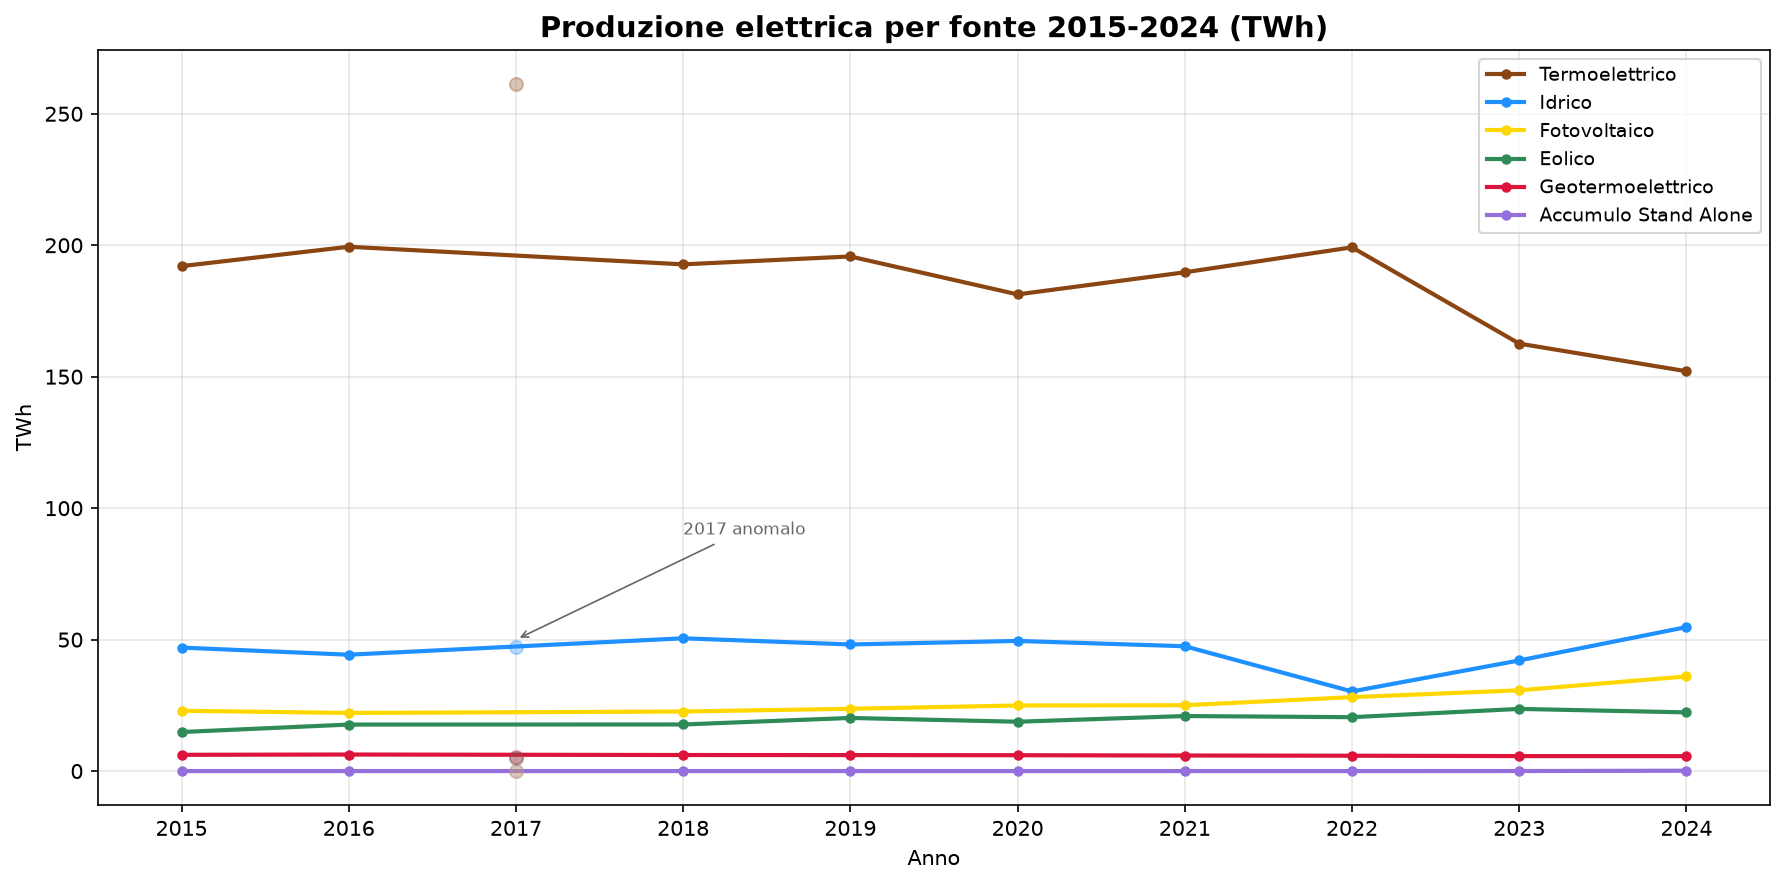

OK - terna_trend_2015_2024.png


In [4]:
# 3. Trend produzione per fonte 2015-2024
COLORI = {
    'Termoelettrico': '#8B4513',
    'Idrico': '#1E90FF',
    'Fotovoltaico': '#FFD700',
    'Eolico': '#2E8B57',
    'Geotermoelettrico': '#DC143C',
    'Accumulo Stand Alone': '#9370DB',
}

fig, ax = plt.subplots(figsize=(12, 6))
anni = sorted(pivot.index)
has_2017 = 2017 in anni

for col in col_order:
    y = pivot[col].values / 1_000
    if has_2017:
        anni_filt = [a for a in anni if a != 2017]
        x_filt = [i for i, a in enumerate(anni) if a != 2017]
        y_filt = [y[i] for i in x_filt]
        ax.plot(anni_filt, y_filt, label=col, color=COLORI.get(col, '#333'),
                linewidth=2, marker='o', markersize=4)
        idx_2017 = anni.index(2017)
        ax.scatter([2017], [y[idx_2017]], color=COLORI.get(col, '#333'),
                   s=40, zorder=5, alpha=0.3)
    else:
        ax.plot(anni, y, label=col, color=COLORI.get(col, '#333'),
                linewidth=2, marker='o', markersize=4)

ax.set_title('Produzione elettrica per fonte 2015-2024 (TWh)', fontsize=14, fontweight='bold')
ax.set_xlabel('Anno')
ax.set_ylabel('TWh')
ax.legend(loc='upper right', fontsize=9)
ax.set_xticks(anni)
ax.set_xticklabels([str(a) for a in anni])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.grid(True, alpha=0.3)
ax.set_xlim(min(anni) - 0.5, max(anni) + 0.5)
if has_2017:
    ax.annotate('2017 anomalo', xy=(2017, 50), xytext=(2018, 90),
                fontsize=8, color='#666',
                arrowprops=dict(arrowstyle='->', color='#666', lw=0.8))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'terna_trend_2015_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print('OK - terna_trend_2015_2024.png')

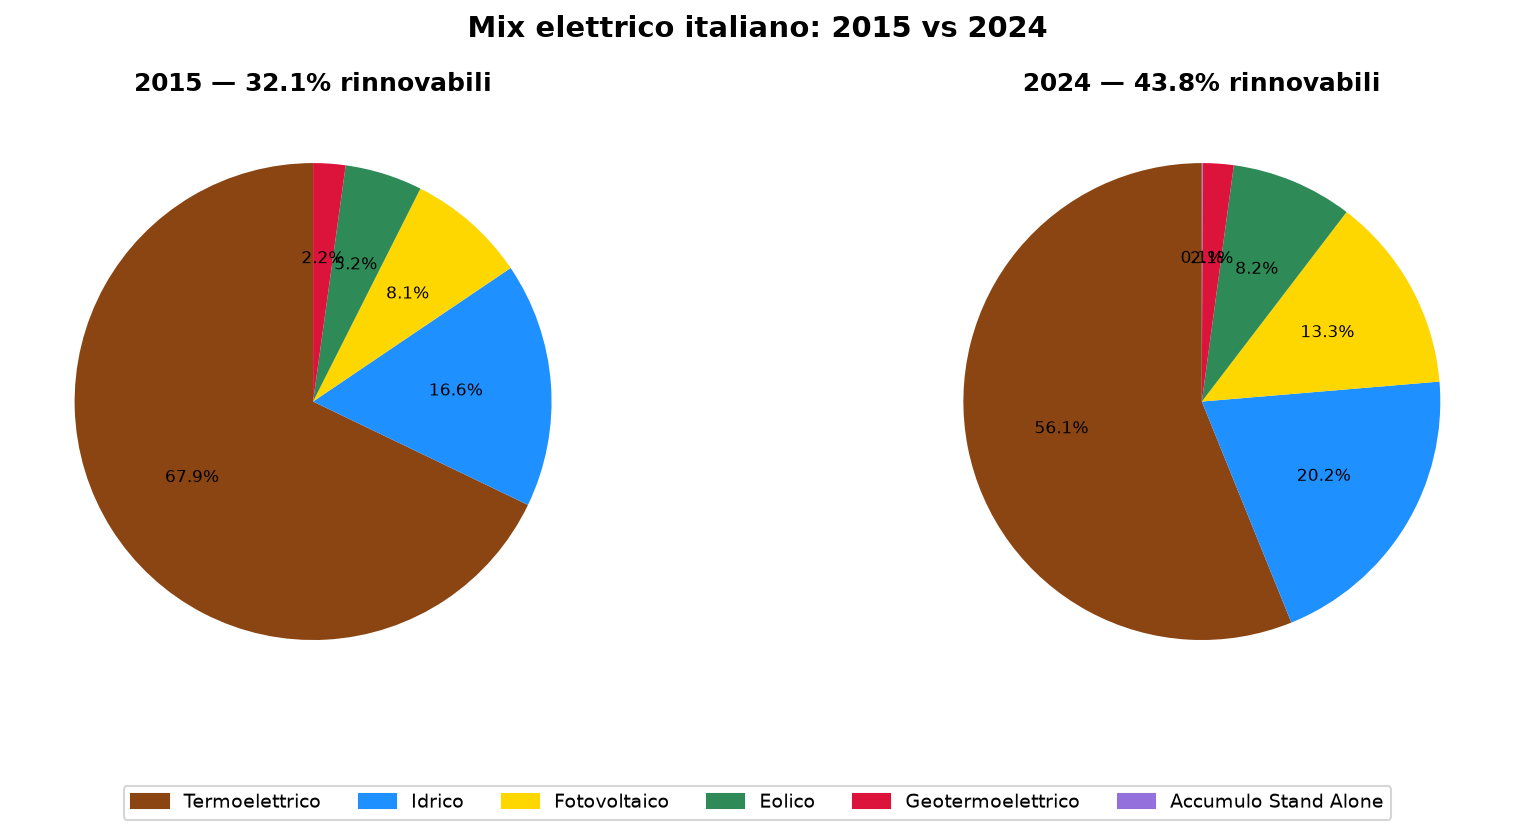

OK - terna_mix_2015_2024.png


In [5]:
# 4. Confronto mix 2015 vs 2024
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, anno in [(ax1, 2015), (ax2, 2024)]:
    row = pivot.loc[anno, col_order]
    labels = [c for c in col_order if row[c] > 0]
    sizes = [row[c] for c in labels]
    colors = [COLORI[c] for c in labels]
    ax.pie(sizes, labels=None, autopct='%1.1f%%',
           startangle=90, colors=colors, textprops={'fontsize': 8})
    ax.set_title(f"{anno} — {pivot.loc[anno, 'quota_rinnovabili']}% rinnovabili",
                 fontsize=12, fontweight='bold')

fig.legend(
    [plt.Rectangle((0,0),1,1,color=COLORI[c]) for c in col_order],
    col_order, loc='lower center', ncol=len(col_order), fontsize=9
)
plt.suptitle('Mix elettrico italiano: 2015 vs 2024', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig(FIGURES_DIR / 'terna_mix_2015_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print('OK - terna_mix_2015_2024.png')

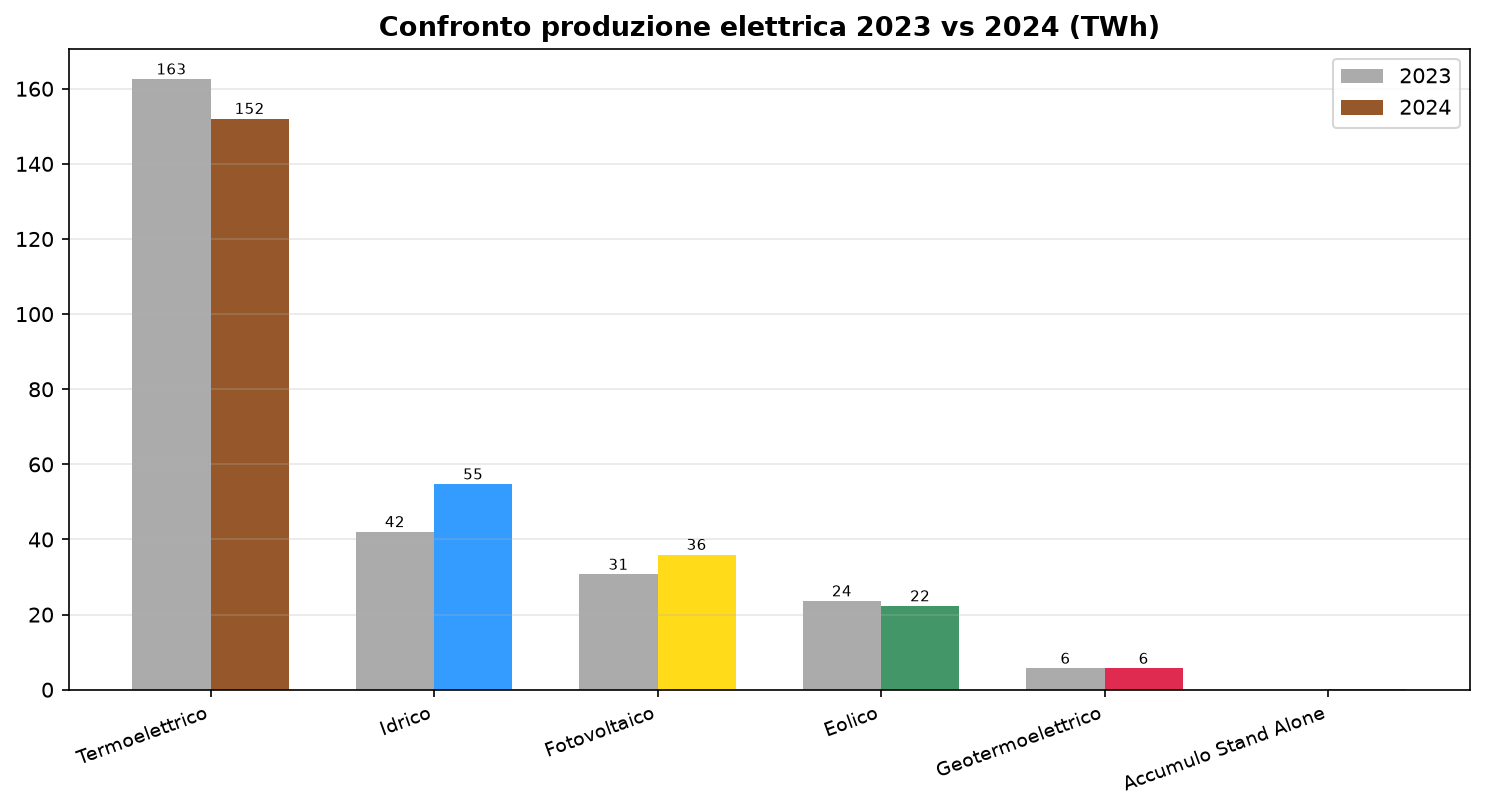

OK - terna_barre_2023_2024.png


In [6]:
# 5. Confronto barre 2023 vs 2024
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(col_order))
width = 0.35

vals_2023 = [pivot.loc[2023, c] / 1_000 for c in col_order]
vals_2024 = [pivot.loc[2024, c] / 1_000 for c in col_order]

ax.bar(x - width/2, vals_2023, width, label='2023', color='#888', alpha=0.7)
ax.bar(x + width/2, vals_2024, width, label='2024',
       color=[COLORI[c] for c in col_order], alpha=0.9)

ax.set_title('Confronto produzione elettrica 2023 vs 2024 (TWh)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(col_order, fontsize=9, rotation=20, ha='right')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.grid(True, alpha=0.3, axis='y')

for bars in [ax.containers[0], ax.containers[1]]:
    for bar in bars:
        h = bar.get_height()
        if h > 1:
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.3,
                    f'{h:.0f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'terna_barre_2023_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print('OK - terna_barre_2023_2024.png')

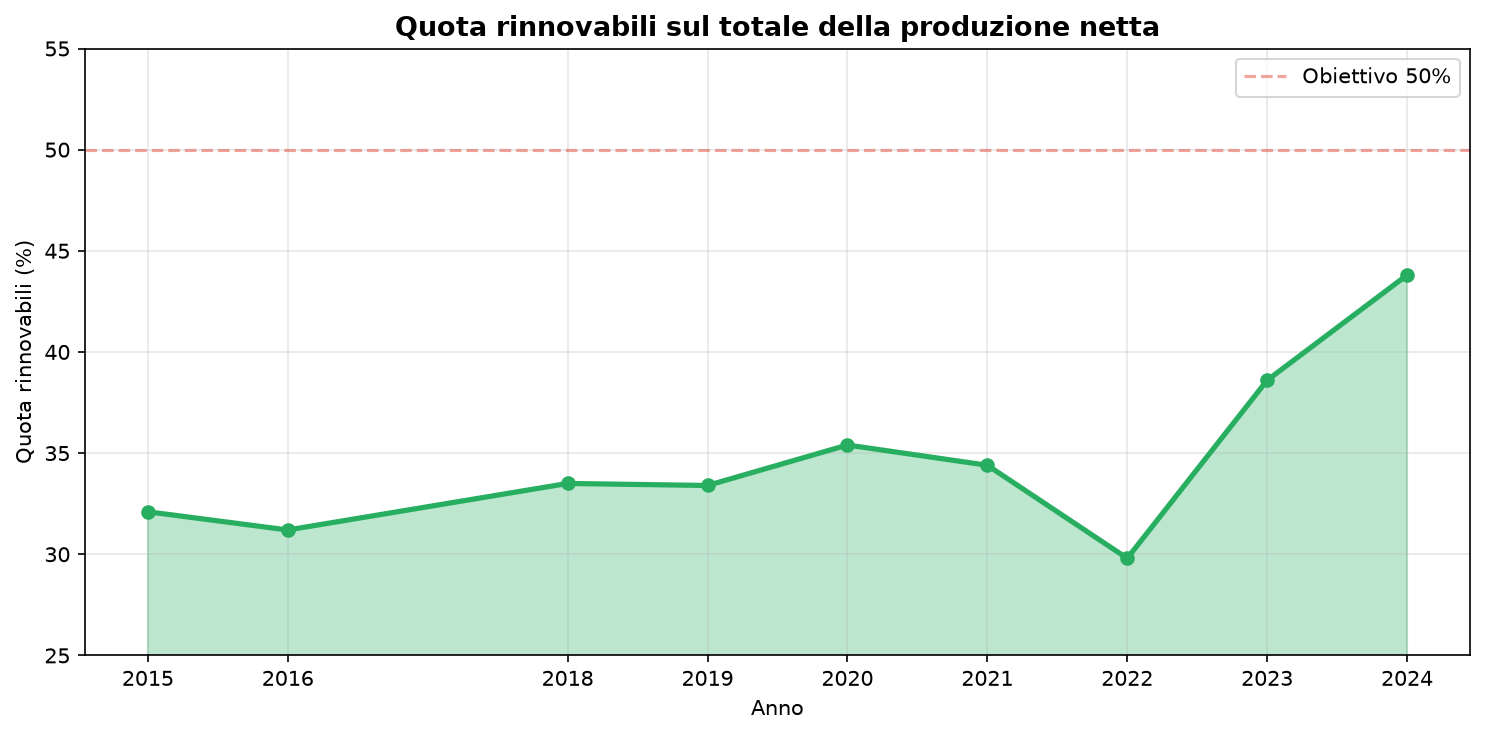

OK - terna_quota_rinnovabili.png


In [7]:
# 6. Quota rinnovabili per anno
anni_filt = [a for a in anni if a != 2017]
fig, ax = plt.subplots(figsize=(10, 5))

y_rinn = [pivot.loc[a, 'quota_rinnovabili'] for a in anni_filt]
ax.fill_between(anni_filt, y_rinn, alpha=0.3, color='#27ae60')
ax.plot(anni_filt, y_rinn, color='#27ae60', linewidth=2.5, marker='o', markersize=6)
ax.axhline(y=50, color='#e74c3c', linestyle='--', alpha=0.5, label='Obiettivo 50%')

ax.set_title('Quota rinnovabili sul totale della produzione netta', fontsize=13, fontweight='bold')
ax.set_xlabel('Anno')
ax.set_ylabel('Quota rinnovabili (%)')
ax.set_xticks(anni_filt)
ax.set_xticklabels([str(a) for a in anni_filt])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(25, 55)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'terna_quota_rinnovabili.png', dpi=150, bbox_inches='tight')
plt.show()
print('OK - terna_quota_rinnovabili.png')

In [8]:
# 7. Variazioni 2015 -> 2024
print('=' * 65)
print('VARIAZIONI 2015 -> 2024')
print('=' * 65)
for col in col_order:
    v15 = pivot.loc[2015, col]
    v24 = pivot.loc[2024, col]
    d = v24 - v15
    p = (d / v15 * 100) if v15 != 0 else float('inf')
    print(f'{col:30s} {v15:>8,} -> {v24:>8,} GWh  ({d:+,} GWh, {p:+.1f}%)')

print()
t15 = pivot.loc[2015, 'totale']
t24 = pivot.loc[2024, 'totale']
print(f"{'TOTALE':30s} {t15:>8,} -> {t24:>8,} GWh  ({t24-t15:+,} GWh, {(t24-t15)/t15*100:+.1f}%)")
print()
print(f'Quota rinnovabili 2015: {pivot.loc[2015, "quota_rinnovabili"]}%')
print(f'Quota rinnovabili 2024: {pivot.loc[2024, "quota_rinnovabili"]}%')
print(f'Delta: {pivot.loc[2024, "quota_rinnovabili"] - pivot.loc[2015, "quota_rinnovabili"]:+.1f} pp')

VARIAZIONI 2015 -> 2024
Termoelettrico                  192,054 ->  152,080 GWh  (-39,974 GWh, -20.8%)
Idrico                           46,969 ->   54,757 GWh  (+7,788 GWh, +16.6%)
Fotovoltaico                     22,942 ->   35,993 GWh  (+13,051 GWh, +56.9%)
Eolico                           14,844 ->   22,322 GWh  (+7,478 GWh, +50.4%)
Geotermoelettrico                 6,185 ->    5,675 GWh  (-510 GWh, -8.2%)
Accumulo Stand Alone                  0 ->      136 GWh  (+136 GWh, +inf%)

TOTALE                          282,994 ->  270,963 GWh  (-12,031 GWh, -4.3%)

Quota rinnovabili 2015: 32.1%
Quota rinnovabili 2024: 43.8%
Delta: +11.7 pp


In [9]:
# 8. Cleanup
con.close()
print('Connessione chiusa.')
print('Figure:', sorted([p.name for p in FIGURES_DIR.glob('*.png')]))

Connessione chiusa.
Figure: ['terna_barre_2023_2024.png', 'terna_mix_2015_2024.png', 'terna_mix_2023_2024.png', 'terna_quota_rinnovabili.png', 'terna_trend_2015_2024.png']
